In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Настройки отображения
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Загружаем данные
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print(f'Размер датасета: {df.shape}')
print(f'Строк: {df.shape[0]:,}')
print(f'Колонок: {df.shape[1]}')
df.head()

Размер датасета: (150000, 11)
Строк: 150,000
Колонок: 11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [18]:
# Типы данных и пропуски
print('=== Типы данных ===')
print(df.dtypes)
print()

# Пропущенные значения
print('=== Пропущенные значения ===')
missing = pd.DataFrame({
    'Количество': df.isnull().sum(),
    'Процент': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Количество'] > 0])
print()

# Базовая статистика
print('=== Базовая статистика ===')
df.describe()

=== Типы данных ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== Пропущенные значения ===
                    Количество  Процент
MonthlyIncome            29731    19.82
NumberOfDependents        3924     2.62

=== Базовая статистика ===


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


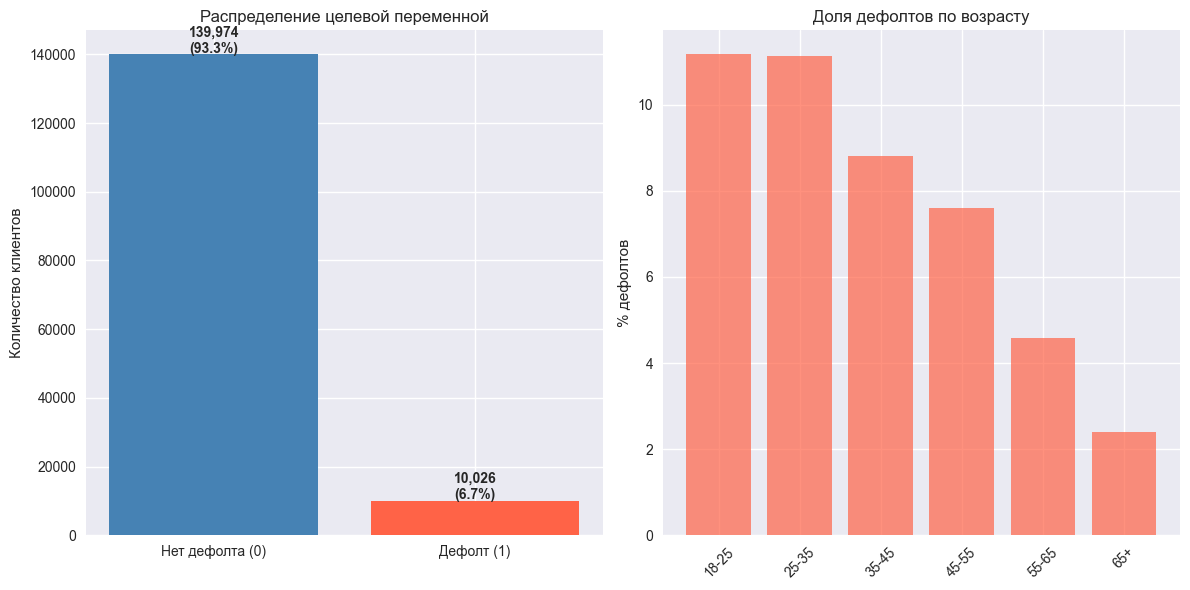


Дефолт: 10,026 клиентов (6.7%)
Норма:  139,974 клиентов (93.3%)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# График 1 — распределение классов
target_counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(['Нет дефолта (0)', 'Дефолт (1)'], 
            target_counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество клиентов')

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontweight='bold')

# График 2 — доля дефолтов по возрасту
df_clean_age = df[df['age'].between(18, 100)]
age_bins = pd.cut(df_clean_age['age'], bins=[18,25,35,45,55,65,100])
default_by_age = df_clean_age.groupby(age_bins)['SeriousDlqin2yrs'].mean() * 100

axes[1].bar(range(len(default_by_age)), 
            default_by_age.values,
            color='tomato', alpha=0.7)
axes[1].set_xticks(range(len(default_by_age)))
axes[1].set_xticklabels(['18-25','25-35','35-45','45-55','55-65','65+'], rotation=45)
axes[1].set_title('Доля дефолтов по возрасту')
axes[1].set_ylabel('% дефолтов')

plt.tight_layout()
plt.savefig('../data/target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nДефолт: {target_counts[1]:,} клиентов ({target_counts[1]/len(df)*100:.1f}%)")
print(f"Норма:  {target_counts[0]:,} клиентов ({target_counts[0]/len(df)*100:.1f}%)")

In [20]:
# Смотрим на подозрительные колонки которые нашли ранее
print('=== Выбросы ===')

# RevolvingUtilization должна быть от 0 до 1 (это доля использования кредита)
print(f'RevolvingUtilization > 1: {(df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()} записей')
print(f'RevolvingUtilization max: {df["RevolvingUtilizationOfUnsecuredLines"].max():.0f}')

# Возраст
print(f'\nВозраст = 0: {(df["age"] == 0).sum()} записей')
print(f'Возраст > 100: {(df["age"] > 100).sum()} записей')
print(f'Возраст max: {df["age"].max()}')

# DebtRatio
print(f'\nDebtRatio > 1: {(df["DebtRatio"] > 1).sum()} записей')
print(f'DebtRatio max: {df["DebtRatio"].max():.0f}')

# Просрочки — логически не могут быть очень большими
print(f'\nNumberOfTime30-59 > 90: {(df["NumberOfTime30-59DaysPastDueNotWorse"] > 90).sum()} записей')
print(f'NumberOfTime30-59 max: {df["NumberOfTime30-59DaysPastDueNotWorse"].max()}')

=== Выбросы ===
RevolvingUtilization > 1: 3321 записей
RevolvingUtilization max: 50708

Возраст = 0: 1 записей
Возраст > 100: 13 записей
Возраст max: 109

DebtRatio > 1: 35137 записей
DebtRatio max: 329664

NumberOfTime30-59 > 90: 269 записей
NumberOfTime30-59 max: 98


In [21]:
df_clean = df.copy()
# Выбросы:

# RevolvingUtilization: обрезаем до 1 (капируем выбросы)
# Значения > 1 заменяем на 1 (максимально возможное)
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean[
    'RevolvingUtilizationOfUnsecuredLines'
].clip(0, 1)

# Возраст: убираем невозможные значения
# 0 лет и > 100 лет — заменяем на медиану
age_median = df_clean.loc[df_clean['age'].between(18, 100), 'age'].median()
df_clean.loc[df_clean['age'] == 0, 'age'] = age_median
df_clean.loc[df_clean['age'] > 100, 'age'] = age_median

# DebtRatio: обрезаем сильные выбросы на уровне 99-го перцентиля
debt_99 = df_clean['DebtRatio'].quantile(0.99)
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(0, debt_99)

# Просрочки 98 — скорее всего кодовое значение "много"
# Заменяем на 90-й перцентиль
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    p90 = df_clean.loc[df_clean[col] < 90, col].quantile(0.90)
    df_clean.loc[df_clean[col] >= 90, col] = p90

# ── ПРОПУСКИ ─────────────────────────────────────────────────────

# MonthlyIncome: 19.8% пропусков — заполняем медианой
# Медиана лучше среднего при выбросах
income_median = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(income_median)

# NumberOfDependents: 2.6% пропусков — заполняем медианой (0)
dep_median = df_clean['NumberOfDependents'].median()
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(dep_median)

# ── ПРОВЕРКА ─────────────────────────────────────────────────────
print('Пропуски после очистки:')
print(df_clean.isnull().sum())
print(f'\nФорма данных: {df_clean.shape}')
print(f'RevolvingUtilization max: {df_clean["RevolvingUtilizationOfUnsecuredLines"].max():.2f}')
print(f'Возраст max: {df_clean["age"].max()}')
print(f'DebtRatio max: {df_clean["DebtRatio"].max():.1f}')

Пропуски после очистки:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Форма данных: (150000, 11)
RevolvingUtilization max: 1.00
Возраст max: 99
DebtRatio max: 4979.0


In [22]:
# Создаём новые признаки на основе финансовой логики
df_feat = df_clean.copy()

# Признак 1: общее количество просрочек любой длины
# Логика: клиент с любыми просрочками более рискованный
df_feat['TotalLatePayments'] = (
    df_feat['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_feat['NumberOfTimes90DaysLate'] +
    df_feat['NumberOfTime60-89DaysPastDueNotWorse']
)

# Признак 2: флаг — есть ли хоть одна просрочка
# Логика: бинарный сигнал риска
df_feat['HasAnyLatePayment'] = (df_feat['TotalLatePayments'] > 0).astype(int)

# Признак 3: долг на одного члена семьи
# Логика: нагрузка на семью важнее абсолютного долга
df_feat['DebtPerDependent'] = df_feat['DebtRatio'] / (
    df_feat['NumberOfDependents'] + 1  # +1 чтобы избежать деления на 0
)

# Признак 4: возрастная группа риска (молодой = выше риск по графику выше)
df_feat['IsYoung'] = (df_feat['age'] < 35).astype(int)

# Признак 5: кредитная нагрузка (кредитов на уровень дохода)
# Логика: много кредитов при низком доходе = риск
df_feat['LoansPerIncome'] = df_feat['NumberOfOpenCreditLinesAndLoans'] / (
    df_feat['MonthlyIncome'] + 1
)

print('Новые признаки:')
new_features = ['TotalLatePayments', 'HasAnyLatePayment', 
                'DebtPerDependent', 'IsYoung', 'LoansPerIncome']
print(df_feat[new_features].describe().round(3))
print(f'\nИтого признаков: {df_feat.shape[1]}')

Новые признаки:
       TotalLatePayments  HasAnyLatePayment  DebtPerDependent     IsYoung  \
count         150000.000         150000.000        150000.000  150000.000   
mean               0.402              0.202           270.917       0.128   
std                1.101              0.402           809.604       0.334   
min                0.000              0.000             0.000       0.000   
25%                0.000              0.000             0.090       0.000   
50%                0.000              0.000             0.228       0.000   
75%                0.000              0.000             0.702       0.000   
max               19.000              1.000          4979.040       1.000   

       LoansPerIncome  
count      150000.000  
mean            0.094  
std             0.934  
min             0.000  
25%             0.001  
50%             0.001  
75%             0.002  
max            31.000  

Итого признаков: 16


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [24]:
# ── ПОДГОТОВКА ДАННЫХ ─────────────────────────────────────────────

# Отделяем признаки от целевой переменной
X = df_feat.drop('SeriousDlqin2yrs', axis=1)
y = df_feat['SeriousDlqin2yrs']

# Делим на train и test (80% / 20%)
# stratify=y — сохраняем пропорцию классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} записей')
print(f'Test:  {X_test.shape[0]:,} записей')
print(f'Дефолтов в train: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Дефолтов в test:  {y_test.sum():,} ({y_test.mean()*100:.1f}%)')


Train: 120,000 записей
Test:  30,000 записей
Дефолтов в train: 8,021 (6.7%)
Дефолтов в test:  2,005 (6.7%)


In [25]:
# ── МОДЕЛЬ 1: LOGISTIC REGRESSION ────────────────────────────────

# Логистическая регрессия чувствительна к масштабу — нужна нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # transform (не fit!) на тесте

# class_weight='balanced' — автоматически учитывает дисбаланс классов
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_roc   = roc_auc_score(y_test, lr_proba)
lr_pr    = average_precision_score(y_test, lr_proba)

print(f'\n── Logistic Regression ──')
print(f'ROC-AUC:  {lr_roc:.4f}')
print(f'PR-AUC:   {lr_pr:.4f}')


── Logistic Regression ──
ROC-AUC:  0.8618
PR-AUC:   0.3888


In [26]:
# ── МОДЕЛЬ 2: GRADIENT BOOSTING ──────────────────────────────────

# Бустинг не требует нормализации
gb = GradientBoostingClassifier(
    n_estimators=100,    # количество деревьев
    max_depth=4,         # глубина каждого дерева
    learning_rate=0.1,   # шаг обучения
    random_state=42
)
gb.fit(X_train, y_train)  # без скейлинга

gb_proba = gb.predict_proba(X_test)[:, 1]
gb_roc   = roc_auc_score(y_test, gb_proba)
gb_pr    = average_precision_score(y_test, gb_proba)

print(f'\n── Gradient Boosting ──')
print(f'ROC-AUC:  {gb_roc:.4f}')
print(f'PR-AUC:   {gb_pr:.4f}')


── Gradient Boosting ──
ROC-AUC:  0.8680
PR-AUC:   0.3998


In [27]:

# ── СРАВНЕНИЕ ─────────────────────────────────────────────────────
print(f'\n{"Метрика":<12} {"LogReg":>10} {"GradBoost":>10}')
print('-' * 34)
print(f'{"ROC-AUC":<12} {lr_roc:>10.4f} {gb_roc:>10.4f}')
print(f'{"PR-AUC":<12} {lr_pr:>10.4f} {gb_pr:>10.4f}')
winner = "GradBoost" if gb_pr > lr_pr else "LogReg"
print(f'\nЛучшая модель по PR-AUC: {winner}')


Метрика          LogReg  GradBoost
----------------------------------
ROC-AUC          0.8618     0.8680
PR-AUC           0.3888     0.3998

Лучшая модель по PR-AUC: GradBoost


In [28]:
import pickle

# Сохраняем GradBoost как лучшую модель
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(gb, f)

# Сохраняем scaler отдельно 
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Сохраняем список признаков — важно для API
feature_names = list(X.columns)
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print('Сохранено:')
print('  models/model.pkl')
print('  models/scaler.pkl')
print('  models/feature_names.pkl')
print(f'\nПризнаки модели ({len(feature_names)}):')
for i, f in enumerate(feature_names, 1):
    print(f'  {i:2}. {f}')

Сохранено:
  models/model.pkl
  models/scaler.pkl
  models/feature_names.pkl

Признаки модели (15):
   1. RevolvingUtilizationOfUnsecuredLines
   2. age
   3. NumberOfTime30-59DaysPastDueNotWorse
   4. DebtRatio
   5. MonthlyIncome
   6. NumberOfOpenCreditLinesAndLoans
   7. NumberOfTimes90DaysLate
   8. NumberRealEstateLoansOrLines
   9. NumberOfTime60-89DaysPastDueNotWorse
  10. NumberOfDependents
  11. TotalLatePayments
  12. HasAnyLatePayment
  13. DebtPerDependent
  14. IsYoung
  15. LoansPerIncome


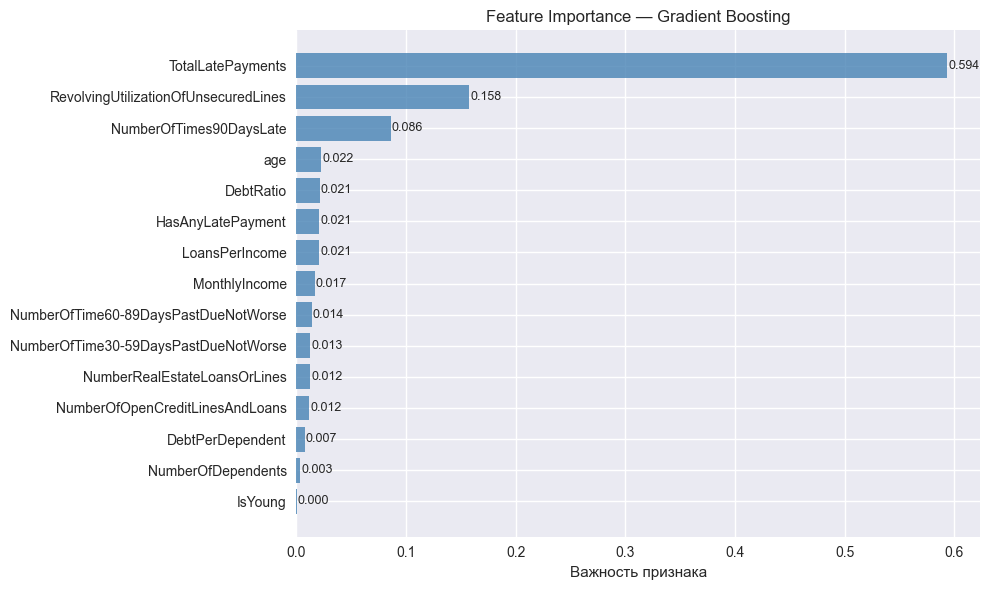

Топ-5 важных признаков:
  1. TotalLatePayments                             0.5936
  2. RevolvingUtilizationOfUnsecuredLines          0.1576
  3. NumberOfTimes90DaysLate                       0.0859
  4. age                                           0.0224
  5. DebtRatio                                     0.0212


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# атрибут feature_importances_
# Показывает насколько каждый признак важен для модели (от 0 до 1, сумма = 1)
importances = gb.feature_importances_
feature_names_list = list(X.columns)

# Сортируем по важности 
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names_list[i] for i in indices]
sorted_importances = importances[indices]

#  график
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    range(len(sorted_features)),
    sorted_importances[::-1],  # переворачиваем 
    color='steelblue',
    alpha=0.8
)
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features[::-1])
ax.set_xlabel('Важность признака')
ax.set_title('Feature Importance — Gradient Boosting')

# значения на столбцы
for i, (bar, val) in enumerate(zip(bars, sorted_importances[::-1])):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Топ-5 признаков текстом
print('Топ-5 важных признаков:')
for i in range(5):
    print(f'  {i+1}. {sorted_features[i]:<45} {sorted_importances[i]:.4f}')

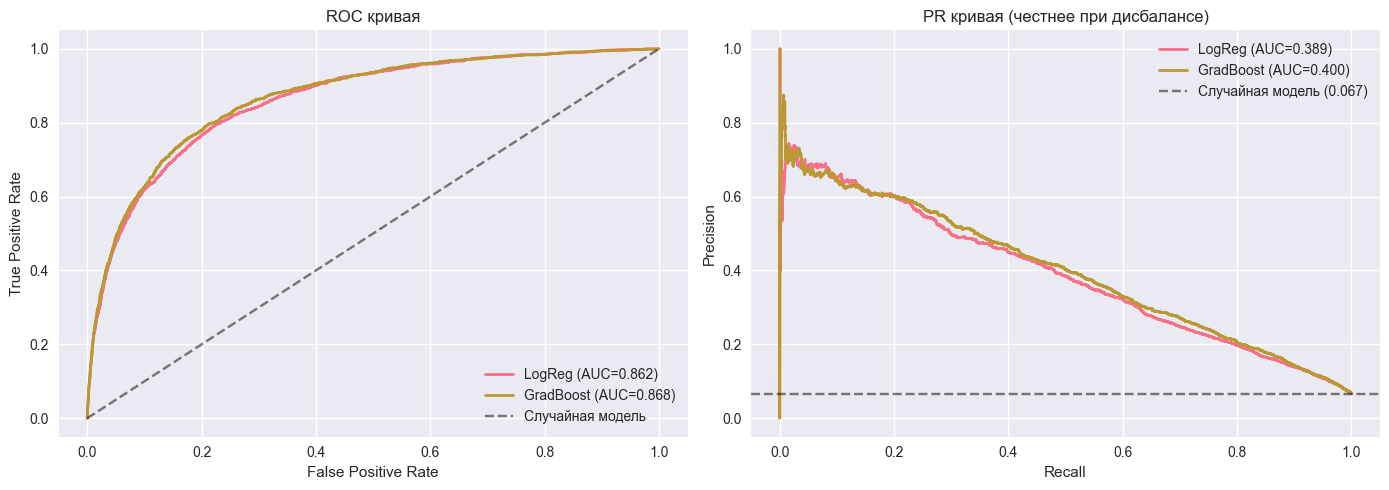

In [30]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC кривая
# Считаем TPR и FPR при разных порогах
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

axes[0].plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={lr_roc:.3f})', linewidth=2)
axes[0].plot(fpr_gb, tpr_gb, label=f'GradBoost (AUC={gb_roc:.3f})', linewidth=2)

# Диагональ — случайная модель для сравнения
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5, label='Случайная модель')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC кривая')
axes[0].legend()

#  PR кривая 
# Честнее при дисбалансе классов
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_proba)
prec_gb, rec_gb, _ = precision_recall_curve(y_test, gb_proba)

axes[1].plot(rec_lr, prec_lr, label=f'LogReg (AUC={lr_pr:.3f})', linewidth=2)
axes[1].plot(rec_gb, prec_gb, label=f'GradBoost (AUC={gb_pr:.3f})', linewidth=2)

# Baseline — случайная модель при дисбалансе = доля положительного класса
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--',
                alpha=0.5, label=f'Случайная модель ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR кривая (честнее при дисбалансе)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Стандартный порог 0.5:
  F1: 0.2797

Оптимальный порог 0.23:
  F1: 0.4477

Confusion Matrix при пороге 0.23:
  TN (правильно норма):    26,599
  FP (ложная тревога):     1,396
  FN (пропущен дефолт):   1,024
  TP (пойман дефолт):     981

  Recall (% пойманных дефолтов): 48.9%
  Precision (точность):          41.3%


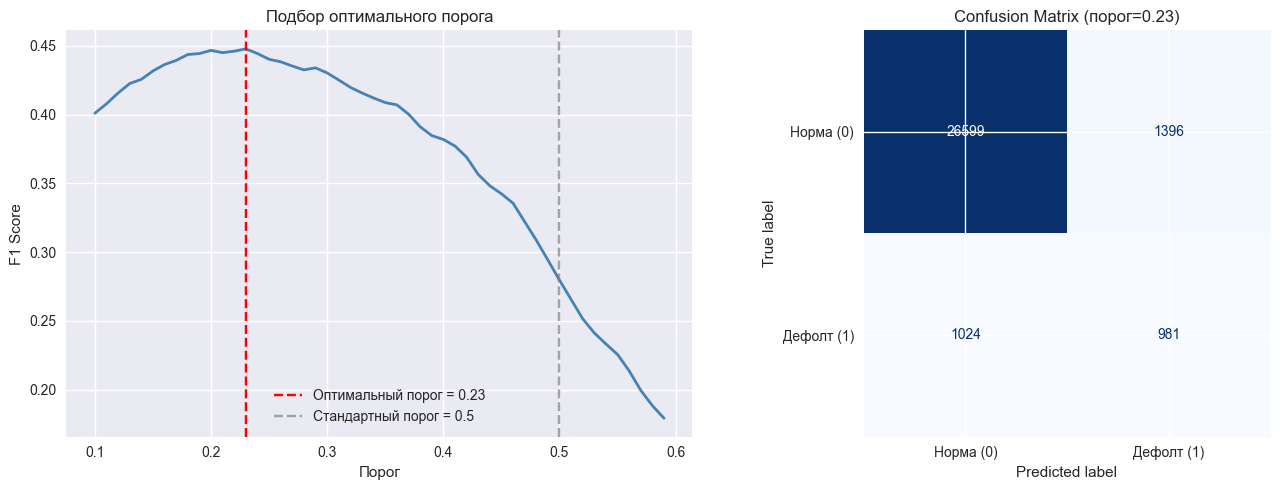

In [31]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# ПОДБОР ПОРОГА 

# Перебираем пороги и ищем лучший по F1

thresholds = np.arange(0.1, 0.6, 0.01)
f1_scores  = []

for t in thresholds:
    preds = (gb_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

# Лучший порог
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f'Стандартный порог 0.5:')
preds_05 = (gb_proba >= 0.5).astype(int)
print(f'  F1: {f1_score(y_test, preds_05):.4f}')

print(f'\nОптимальный порог {best_threshold:.2f}:')
preds_best = (gb_proba >= best_threshold).astype(int)
print(f'  F1: {best_f1:.4f}')

# ГРАФИК ПОРОГА 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 по порогам
axes[0].plot(thresholds, f1_scores, linewidth=2, color='steelblue')
axes[0].axvline(x=best_threshold, color='red', linestyle='--',
                label=f'Оптимальный порог = {best_threshold:.2f}')
axes[0].axvline(x=0.5, color='gray', linestyle='--',
                alpha=0.7, label='Стандартный порог = 0.5')
axes[0].set_xlabel('Порог')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Подбор оптимального порога')
axes[0].legend()

#  CONFUSION MATRIX 
cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Норма (0)', 'Дефолт (1)']
)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix (порог={best_threshold:.2f})')

# Добавляем пояснения к квадратам
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion Matrix при пороге {best_threshold:.2f}:')
print(f'  TN (правильно норма):    {tn:,}')
print(f'  FP (ложная тревога):     {fp:,}')
print(f'  FN (пропущен дефолт):   {fn:,}')
print(f'  TP (пойман дефолт):     {tp:,}')
print(f'\n  Recall (% пойманных дефолтов): {tp/(tp+fn)*100:.1f}%')
print(f'  Precision (точность):          {tp/(tp+fp)*100:.1f}%')

plt.tight_layout()
plt.savefig('../data/threshold_and_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# (локальная папк хранения)
mlflow.set_tracking_uri("../mlruns")

# Название эксперимента 
mlflow.set_experiment("credit-scoring")

# Параметры перебора
experiments = [
    {
        "name": "LogisticRegression_baseline",
        "model": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
        "params": {"model_type": "LogisticRegression", "class_weight": "balanced"},
        "needs_scaling": True
    },
    {
        "name": "GradBoost_baseline",
        "model": GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                             learning_rate=0.1, random_state=42),
        "params": {"model_type": "GradientBoosting", "n_estimators": 100,
                   "max_depth": 4, "learning_rate": 0.1},
        "needs_scaling": False
    },
    {
        "name": "GradBoost_deeper",
        "model": GradientBoostingClassifier(n_estimators=200, max_depth=6,
                                             learning_rate=0.05, random_state=42),
        "params": {"model_type": "GradientBoosting", "n_estimators": 200,
                   "max_depth": 6, "learning_rate": 0.05},
        "needs_scaling": False
    }
]

print("Запускаем эксперименты...")

for exp in experiments:
    # Каждый with mlflow.start_run() = один запуск в UI
    with mlflow.start_run(run_name=exp["name"]):

        # Логируем параметры
        mlflow.log_params(exp["params"])

        # Обучаем модель
        if exp["needs_scaling"]:
            exp["model"].fit(X_train_scaled, y_train)
            proba = exp["model"].predict_proba(X_test_scaled)[:, 1]
        else:
            exp["model"].fit(X_train, y_train)
            proba = exp["model"].predict_proba(X_test)[:, 1]

        # Считаем метрики
        roc   = roc_auc_score(y_test, proba)
        pr    = average_precision_score(y_test, proba)
        preds = (proba >= 0.23).astype(int)
        f1    = f1_score(y_test, preds)

        # Логируем метрики
        mlflow.log_metrics({
            "roc_auc": round(roc, 4),
            "pr_auc":  round(pr, 4),
            "f1":      round(f1, 4)
        })

        # Сохраняем модель как артефакт
        mlflow.sklearn.log_model(exp["model"], "model")

        print(f"  {exp['name']:<35} ROC={roc:.4f}  PR={pr:.4f}  F1={f1:.4f}")

print("\nВсе эксперименты сохранены!")
print("Запусти: mlflow ui --backend-store-uri ../mlruns")

2026/04/03 12:59:40 INFO mlflow.tracking.fluent: Experiment with name 'credit-scoring' does not exist. Creating a new experiment.


Запускаем эксперименты...


2026/04/03 12:59:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 12:59:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression_baseline         ROC=0.8618  PR=0.3888  F1=0.2158


2026/04/03 13:00:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 13:00:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  GradBoost_baseline                  ROC=0.8680  PR=0.3998  F1=0.4477


2026/04/03 13:01:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 13:01:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  GradBoost_deeper                    ROC=0.8683  PR=0.3922  F1=0.4433

Все эксперименты сохранены!
Запусти: mlflow ui --backend-store-uri ../mlruns
